# Clasificador de paisajes con CNN

En este ejercicio construyo un clasificador automático de paisajes usando una **Red Neuronal Convolucional (CNN)**. El dataset tiene imágenes organizadas en 6 carpetas: `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`.

**Pasos del ejercicio:**
1. Cargar las imágenes desde carpetas y etiquetarlas
2. Inspeccionar visualmente los datos
3. Normalizar los píxeles
4. Diseñar la arquitectura de la red (CNN)
5. Reservar el 20% de train para validación
6. Representar el objeto history
7. Evaluar el modelo con datos de test
8. Visualizar errores del modelo
9. Crear la matriz de confusión

## Configuración inicial

In [1]:
# Defino las rutas donde tengo guardados los datos y las constantes globales
# Modifico estas rutas según dónde tenga el dataset en mi ordenador
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from skimage.io import imread
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Dimensiones a las que redimensiono todas las imágenes
# Usamos 32x32 para que el entrenamiento sea rápido — el enunciado lo pide así
IMAGE_WIDTH    = 32
IMAGE_HEIGHT   = 32
IMAGE_CHANNELS = 3                                  # RGB: Rojo, Verde, Azul
IMAGE_SIZE     = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)

BATCH_SIZE = 32
EPOCHS     = 30

# Rutas al dataset — cambiar según la ubicación en tu ordenador
TRAIN_PATH = "/Users/andoni/Desktop/clasificador_paisajes/seg_train"
TEST_PATH  = "/Users/andoni/Desktop/clasificador_paisajes/seg_test"


## 1. Cargar las imágenes

Recorro las carpetas con `os.listdir()`. Cada subcarpeta es una clase (`forest`, `mountain`...). Por cada imagen:
1. La abro y la redimensiono a 32×32 con `cv2.resize()`
2. La guardo como array numpy en `X`
3. Guardo el nombre de la carpeta como etiqueta en `y`

Al final `X` es un array de forma `(N, 32, 32, 3)` e `y` un array de strings con el nombre de la clase.

In [2]:
def read_data(path, im_size):
    """
    Recorre las subcarpetas de `path`, carga cada imagen, la redimensiona
    a im_size×im_size y devuelve:
      X → array numpy de forma (N, im_size, im_size, 3)
      Y → array de strings con el nombre de la clase (nombre de la carpeta)
    """
    X = []
    Y = []

    # Iteramos sobre cada subcarpeta — cada una es una categoría de paisaje
    for category in os.listdir(path):
        carpeta_categoria = os.path.join(path, category)

        # Descartamos cualquier archivo suelto que no sea carpeta (.DS_Store, etc.)
        if not os.path.isdir(carpeta_categoria):
            continue

        # Iteramos sobre cada archivo de imagen dentro de la carpeta
        for filename in os.listdir(carpeta_categoria):
            ruta = os.path.join(carpeta_categoria, filename)

            # imread carga la imagen como array numpy (alto, ancho, canales)
            image = imread(ruta)

            # cv2.resize la redimensiona a im_size×im_size
            # El modelo necesita que TODAS las imágenes tengan el mismo tamaño
            smallimage = cv2.resize(image, (im_size, im_size))

            X.append(smallimage)
            Y.append(category)   # La etiqueta es el nombre de la carpeta

    return np.array(X), np.array(Y)


# Cargamos train y test por separado
X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH)
X_test,  y_test  = read_data(TEST_PATH,  IMAGE_WIDTH)

print(f"Shape X_train: {X_train.shape}")   # Esperado: (N, 32, 32, 3)
print(f"Shape y_train: {y_train.shape}")   # Esperado: (N,)
print(f"Shape X_test:  {X_test.shape}")
print(f"Shape y_test:  {y_test.shape}")
print(f"Clases encontradas: {np.unique(y_train)}")


Shape X_train: (14034, 32, 32, 3)
Shape y_train: (14034,)
Shape X_test:  (3000, 32, 32, 3)
Shape y_test:  (3000,)
Clases encontradas: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


## 2. Inspección visual de los datos

Antes de entrenar nada, verifico que la carga ha ido bien. Si en la cuadrícula veo una montaña con etiqueta *forest*, hay un error en la carga que debo corregir antes de continuar. También reviso que la distribución de clases esté equilibrada — si una clase tiene el doble de imágenes que las demás, el modelo aprenderá a favorecerla.

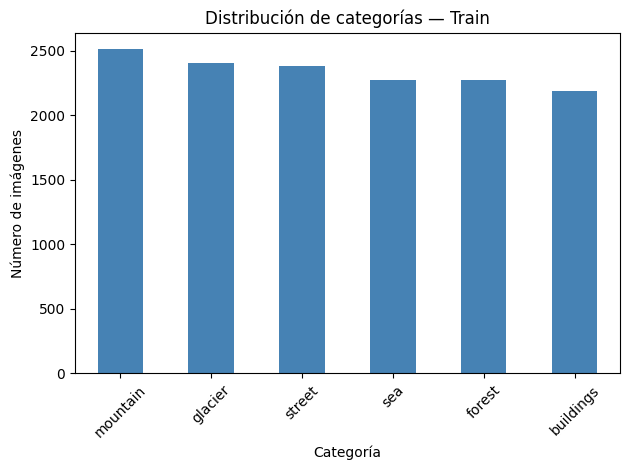

In [3]:
# Distribución de clases: compruebo que no hay un desequilibrio grande
import pandas as pd

pd.Series(y_train).value_counts().plot.bar(color='steelblue')
plt.title('Distribución de categorías — Train')
plt.xlabel('Categoría')
plt.ylabel('Número de imágenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


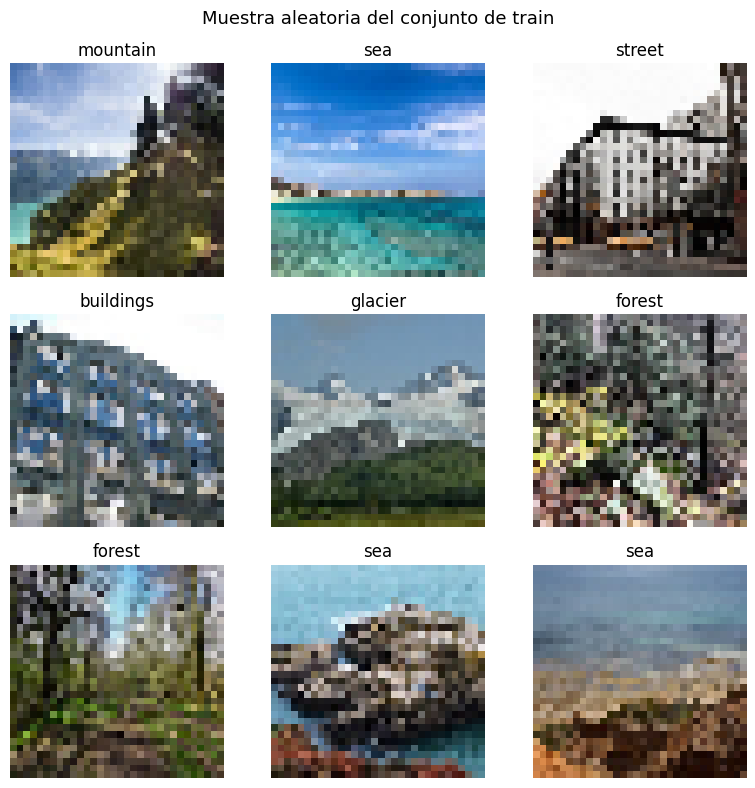

In [4]:
# Mostramos 9 imágenes aleatorias con su etiqueta para verificar que la carga es correcta
# Si título y contenido visual no coinciden, hay un error en el mapeo de etiquetas
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flatten():
    i = random.randint(0, len(X_train) - 1)
    ax.imshow(X_train[i].astype('uint8'))   # astype('uint8') para que matplotlib muestre bien los colores
    ax.set_title(y_train[i])
    ax.axis('off')

plt.suptitle('Muestra aleatoria del conjunto de train', fontsize=13)
plt.tight_layout()
plt.show()


## 3. Normalización

Cada píxel tiene un valor entero entre **0 y 255**. Las redes neuronales convergen mucho mejor cuando los valores de entrada son pequeños. Si dejo los píxeles en escala de 0–255, los gradientes durante el entrenamiento pueden explotar o desvanecerse.

La solución es dividir entre 255.0 para escalar el rango a **[0.0, 1.0]**. 

Importante: aplico exactamente el mismo factor (255) al test. Nunca calculo estadísticas del test para normalizar — eso sería *data leakage* (usar información del test para preprocesar).

Después hago un `shuffle` del train para que el modelo no vea siempre las clases en el mismo orden — así el aprendizaje es más robusto.

In [5]:
# Dividimos entre 255.0 para pasar de [0–255] a [0.0–1.0]
# Mismo divisor fijo en train y test — nunca calculamos stats del test
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"Min: {X_train.min()} | Max: {X_train.max()}")   # Debe ser 0.0 y 1.0


Min: 0.0 | Max: 1.0


In [6]:
# Mezclamos los datos de train aleatoriamente para evitar sesgos
# Si el dataset está ordenado por clase, el modelo vería en cada batch
# solo imágenes de una clase — el aprendizaje sería inestable
X_train, y_train = shuffle(X_train, y_train, random_state=42)


In [7]:
# Las redes neuronales no entienden strings como "forest" o "mountain"
# LabelEncoder convierte cada string a un número entero único:
#   buildings → 0, forest → 1, glacier → 2, mountain → 3, sea → 4, street → 5
# to_categorical convierte ese entero a un vector one-hot de longitud 6:
#   forest (1) → [0, 1, 0, 0, 0, 0]
# Necesitamos one-hot porque usamos categorical_crossentropy como función de pérdida

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)   # fit_transform: aprende el mapeo y lo aplica
y_test_encoded  = le.transform(y_test)        # transform: aplica el mismo mapeo (NO vuelve a aprenderlo)

y_train_cat = to_categorical(y_train_encoded, num_classes=6)
y_test_cat  = to_categorical(y_test_encoded,  num_classes=6)

print(f"Clases y su índice: {list(enumerate(le.classes_))}")
print(f"Shape y_train_cat: {y_train_cat.shape}")    # Esperado: (N, 6)
print(f"Ejemplo — y_train[0] = '{y_train[0]}' → encoded={y_train_encoded[0]} → one-hot={y_train_cat[0]}")


Clases y su índice: [(0, 'buildings'), (1, 'forest'), (2, 'glacier'), (3, 'mountain'), (4, 'sea'), (5, 'street')]
Shape y_train_cat: (14034, 6)
Ejemplo — y_train[0] = 'forest' → encoded=1 → one-hot=[0. 1. 0. 0. 0. 0.]


## 4. Arquitectura de la red neuronal (CNN)

Una **CNN** (Red Neuronal Convolucional) está diseñada específicamente para imágenes. Se compone de dos partes:

### Parte convolucional — *¿qué hay en la imagen?*
- **Conv2D**: aplica filtros que se deslizan por la imagen detectando patrones: bordes, texturas, colores. En el primer bloque detecta patrones simples (bordes rectos, curvas). En el segundo detecta combinaciones (*borde curvo + verde → posible hoja*).
- **MaxPooling2D**: reduce el tamaño de la imagen a la mitad tomando el valor máximo de cada bloque 2×2. Ventaja doble: reduce el coste computacional y hace el modelo robusto a pequeños desplazamientos.

### Parte clasificadora — *¿a qué clase pertenece?*
- **Flatten**: aplana el volumen 3D a un vector 1D. Es el puente entre la parte visual y la clasificadora.
- **Dense**: capa totalmente conectada que aprende: *"si hay agua azul + horizonte → probablemente mar"*.
- **Dropout(0.5)**: durante el entrenamiento apaga aleatoriamente el 50% de las neuronas. Obliga a la red a no depender de ninguna neurona concreta → reduce el *overfitting*.
- **Dense(6, softmax)**: la capa de salida. Convierte los valores en probabilidades que suman 1.0. Una neurona por clase.

In [8]:
model = Sequential([
    # ── BLOQUE 1 ─────────────────────────────────────────────────────────────
    # 32 filtros de 3×3: detectan patrones simples como bordes y cambios de color
    # input_shape le dice al modelo el tamaño de cada imagen de entrada
    # relu = función de activación: pone a 0 los valores negativos
    #        sin relu, apilar capas no añadiría capacidad (todo seguiría siendo lineal)
    Conv2D(32, (3, 3), activation='relu', input_shape=IMAGE_SIZE),

    # MaxPooling reduce 32×32 → 16×16 tomando el máximo de cada bloque 2×2
    MaxPooling2D(2, 2),

    # ── BLOQUE 2 ─────────────────────────────────────────────────────────────
    # 64 filtros: aprende combinaciones de los patrones del bloque 1
    # ("borde curvo + textura verde → posiblemente hoja de árbol")
    # Más filtros porque los patrones de nivel 2 son más variados
    Conv2D(64, (3, 3), activation='relu'),

    # MaxPooling: 16×16 → 8×8
    MaxPooling2D(2, 2),

    # ── PUENTE 2D → 1D ───────────────────────────────────────────────────────
    # Flatten aplana el volumen 3D (8×8×64 = 4096 valores) en un vector 1D
    # Es el puente entre la parte "visual" (Conv) y la parte "clasificadora" (Dense)
    Flatten(),

    # ── CLASIFICADOR ─────────────────────────────────────────────────────────
    # 128 neuronas aprenden razonamiento de alto nivel:
    # "tiene agua + azul + horizonte → probablemente mar"
    Dense(128, activation='relu'),

    # Dropout(0.5): apaga el 50% de neuronas aleatoriamente durante el entrenamiento
    # La red no puede depender de ninguna neurona específica → aprende patrones reales
    # Durante la predicción final no apaga nada — solo actúa en el entrenamiento
    Dropout(0.5),

    # Capa de salida: una neurona por clase
    # softmax convierte los valores en probabilidades que suman 1.0
    # Ejemplo: [0.02, 0.80, 0.03, 0.05, 0.07, 0.03] → clase 1 (forest) con 80%
    Dense(6, activation='softmax')
])

# Configuramos cómo se va a entrenar el modelo:
# - adam: optimizador que ajusta el ritmo de aprendizaje automáticamente
# - categorical_crossentropy: función de pérdida para clasificación multiclase con one-hot
# - accuracy: mostramos el porcentaje de imágenes clasificadas correctamente
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 128)               2

## 5. Entrenamiento con 20% de validación

El modelo aprende ajustando sus pesos internos para minimizar la función de pérdida (*loss*). En cada época ve **todas** las imágenes de train.

Reservo un **20% de los datos de train** para validación (`validation_split=0.2`). Este 20% **no se usa para entrenar** — solo para medir en cada época si el modelo generaliza bien a datos nuevos. Si la *accuracy* de validación se estanca o baja mientras la de train sigue subiendo, hay *overfitting* (el modelo memoriza en vez de aprender).

Añado `EarlyStopping` y `ModelCheckpoint` como callbacks:
- **EarlyStopping**: detiene el entrenamiento si la *val_loss* no mejora en 10 épocas consecutivas. Evita que el modelo sobreajuste en las últimas épocas.
- **ModelCheckpoint**: guarda automáticamente los pesos del mejor modelo (el de menor *val_loss*).

In [9]:
# Callbacks: lógica que se ejecuta automáticamente en cada época
earlystop   = EarlyStopping(patience=10)                                        # Para si val_loss no mejora en 10 épocas
mcheckpoint = ModelCheckpoint("mejor_modelo.keras", save_best_only=True)        # Guarda solo el mejor modelo

history = model.fit(
    X_train, y_train_cat,         # Datos e imágenes con sus etiquetas one-hot
    epochs=EPOCHS,                # Máximo de vueltas completas al dataset
    batch_size=BATCH_SIZE,        # Actualiza pesos cada 32 imágenes (más estable que tras cada imagen)
    validation_split=0.2,         # Reservamos el 20% de train para validar — NO se usa en el entrenamiento
    callbacks=[earlystop, mcheckpoint]
)


Epoch 1/30
351/351 [==============================] - 3s 9ms/step - loss: 1.1808 - accuracy: 0.5342 - val_loss: 0.9108 - val_accuracy: 0.6687
Epoch 2/30
351/351 [==============================] - 3s 9ms/step - loss: 0.9164 - accuracy: 0.6580 - val_loss: 0.8296 - val_accuracy: 0.6961
Epoch 3/30
351/351 [==============================] - 3s 9ms/step - loss: 0.8232 - accuracy: 0.7038 - val_loss: 0.7556 - val_accuracy: 0.7218
Epoch 4/30
351/351 [==============================] - 3s 8ms/step - loss: 0.7452 - accuracy: 0.7361 - val_loss: 0.7578 - val_accuracy: 0.7228
Epoch 5/30
351/351 [==============================] - 3s 9ms/step - loss: 0.6932 - accuracy: 0.7554 - val_loss: 0.6591 - val_accuracy: 0.7592
Epoch 6/30
351/351 [==============================] - 3s 8ms/step - loss: 0.6361 - accuracy: 0.7758 - val_loss: 0.6561 - val_accuracy: 0.7674
Epoch 7/30
351/351 [==============================] - 3s 8ms/step - loss: 0.6028 - accuracy: 0.7884 - val_loss: 0.6431 - val_accuracy: 0.7781
Epoch 

## 6. Representación del objeto history

El objeto `history` almacena la *accuracy* y la *loss* de train y validación en cada época. Es el diagnóstico más importante del entrenamiento:

- **Entrenamiento sano**: ambas curvas suben/bajan juntas y de forma paralela.
- **Overfitting**: la curva de train mejora pero la de validación se estanca o empeora — el modelo memoriza los datos de entrenamiento en vez de aprender patrones generalizables.

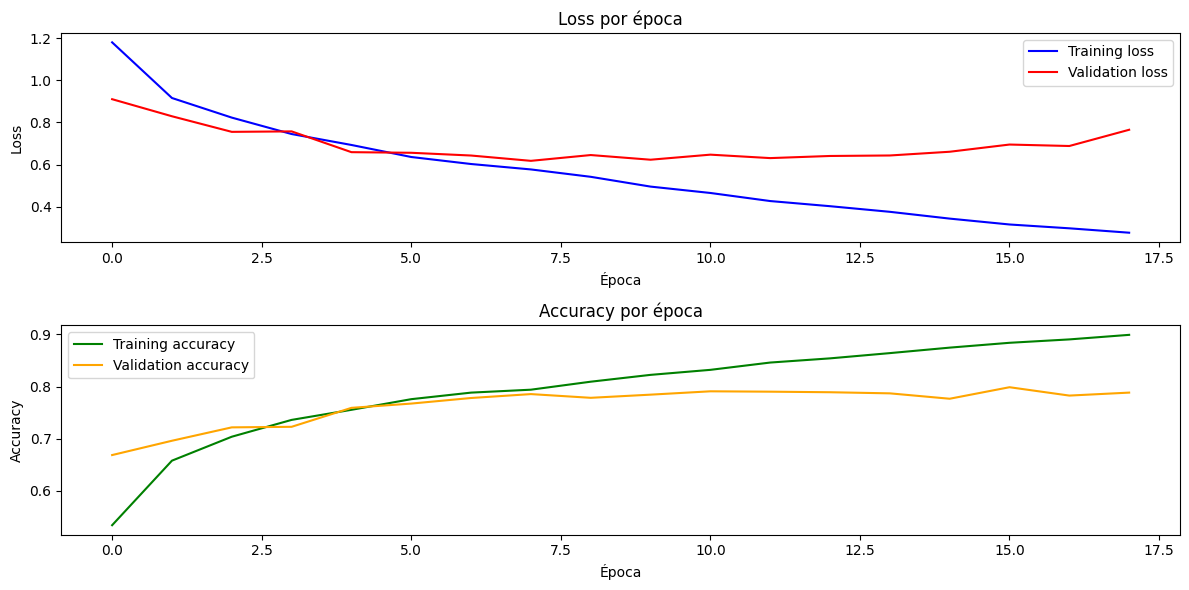

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# ── Gráfica de Loss ───────────────────────────────────────────────────────
ax1.plot(history.history['loss'],     color='b', label='Training loss')
ax1.plot(history.history['val_loss'], color='r', label='Validation loss')
ax1.set_title('Loss por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()

# ── Gráfica de Accuracy ───────────────────────────────────────────────────
ax2.plot(history.history['accuracy'],     color='g',      label='Training accuracy')
ax2.plot(history.history['val_accuracy'], color='orange', label='Validation accuracy')
ax2.set_title('Accuracy por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()


## 7. Evaluación con datos de test

Evalúo el modelo sobre el conjunto de **test**: imágenes que el modelo **nunca ha visto** durante el entrenamiento ni la validación. Esta es la medida más honesta del rendimiento real.

La *accuracy* de test puede ser ligeramente inferior a la de validación — es normal. Lo que sería una señal de alerta es que sea muy inferior (indicaría que el proceso de validación no representó bien la distribución de los datos).

In [11]:
# evaluate() devuelve [loss, accuracy] en datos que el modelo no ha visto nunca
results = model.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nTest loss:     {results[0]:.4f}")
print(f"Test accuracy: {results[1]:.4f}")


94/94 [==============================] - 0s 3ms/step - loss: 0.8225 - accuracy: 0.7760

Test loss:     0.8225
Test accuracy: 0.7760


## 8. Imágenes donde el modelo comete errores

Visualizo ejemplos concretos de errores para entender **en qué clases se confunde** el modelo. Por ejemplo, es lógico que confunda *glacier* con *mountain* porque ambas tienen paisajes nevados. Estas confusiones guían qué mejoras aplicar: más datos, mayor resolución, o una arquitectura más profunda.

In [12]:
# model.predict devuelve las probabilidades para cada clase: shape (N, 6)
# argmax nos da el índice de la clase con mayor probabilidad
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)   # clase predicha (número)
y_true       = y_test_encoded                     # clase real (número)

# Buscamos los índices donde predicción ≠ etiqueta real
errores = np.where(y_pred != y_true)[0]
print(f"Total errores: {len(errores)} de {len(y_true)} imágenes ({len(errores)/len(y_true)*100:.1f}%)")


94/94 [==============================] - 0s 2ms/step
Total errores: 672 de 3000 imágenes (22.4%)


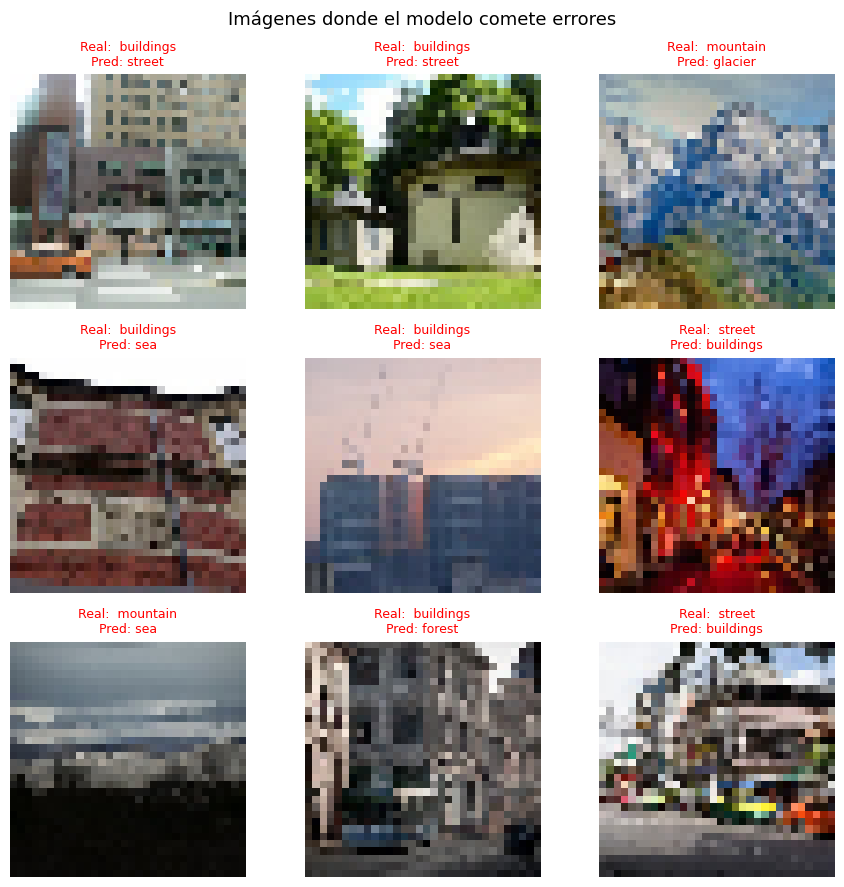

In [13]:
# Mostramos 9 ejemplos de error para analizar en qué se confunde el modelo
# En el título: clase real (verde) vs clase predicha (rojo)
muestra_errores = random.sample(list(errores), min(9, len(errores)))

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax, idx in zip(axes.flatten(), muestra_errores):
    ax.imshow(X_test[idx])
    ax.set_title(
        f"Real:  {le.classes_[y_true[idx]]}\nPred: {le.classes_[y_pred[idx]]}",
        fontsize=9, color='red'
    )
    ax.axis('off')

plt.suptitle('Imágenes donde el modelo comete errores', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Matriz de confusión

La matriz de confusión muestra, para cada clase **real** (filas), cuántas imágenes clasificó el modelo en cada clase **predicha** (columnas).

- **Diagonal principal**: aciertos (cuanto más azul, mejor).
- **Fuera de la diagonal**: errores (el valor indica cuántas imágenes de la clase fila fueron clasificadas como la clase columna).

Si veo que *glacier* → *mountain* tiene un número alto, significa que el modelo confunde sistemáticamente estos dos paisajes, probablemente porque ambos tienen nieve y montañas.

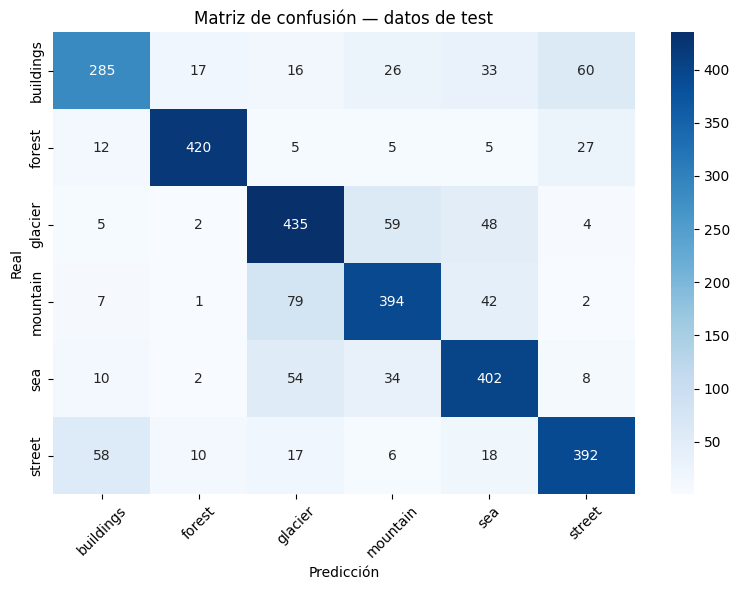

In [14]:
# Calculamos y mostramos la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # Escribe los números dentro de cada celda
    fmt='d',             # Formato entero (sin decimales)
    cmap='Blues',        # Cuanto más azul, más imágenes en esa celda
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matriz de confusión — datos de test')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lectura rápida: la diagonal son los aciertos
# Si "glacier" se confunde con "mountain" → tiene sentido visual: ambas tienen nieve
